# Insurance Claim Costs - Exploratory Data Analysis (EDA)

This notebook analyzes the `insurance.csv` dataset to discover factors affecting insurance claim costs (`charges`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Loading the Dataset and Overview

In [3]:
df = pd.read_csv(r"C:\Users\Emre\Desktop\DataMiningInsurance\DataSet\insurance.csv")
print(f"Dataset size: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset size: 1338 rows, 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

## 2. Missing Values Analysis

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Ratio (%)": missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

          Missing Count  Missing Ratio (%)
age                   0                0.0
sex                   0                0.0
bmi                   0                0.0
children              0                0.0
smoker                0                0.0
region                0                0.0
charges               0                0.0

Total missing values: 0


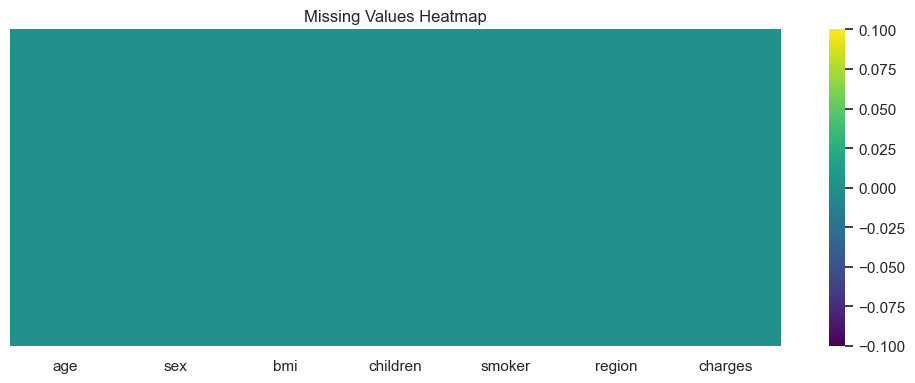

In [7]:
# Missing values heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

## 3. Statistical Summary

In [8]:
# Numerical variables
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
# Categorical variables
df.describe(include="object")

C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\3651821800.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [10]:
# Categorical variable distributions
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\690926515.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## 4. Target Variable (charges) Distribution

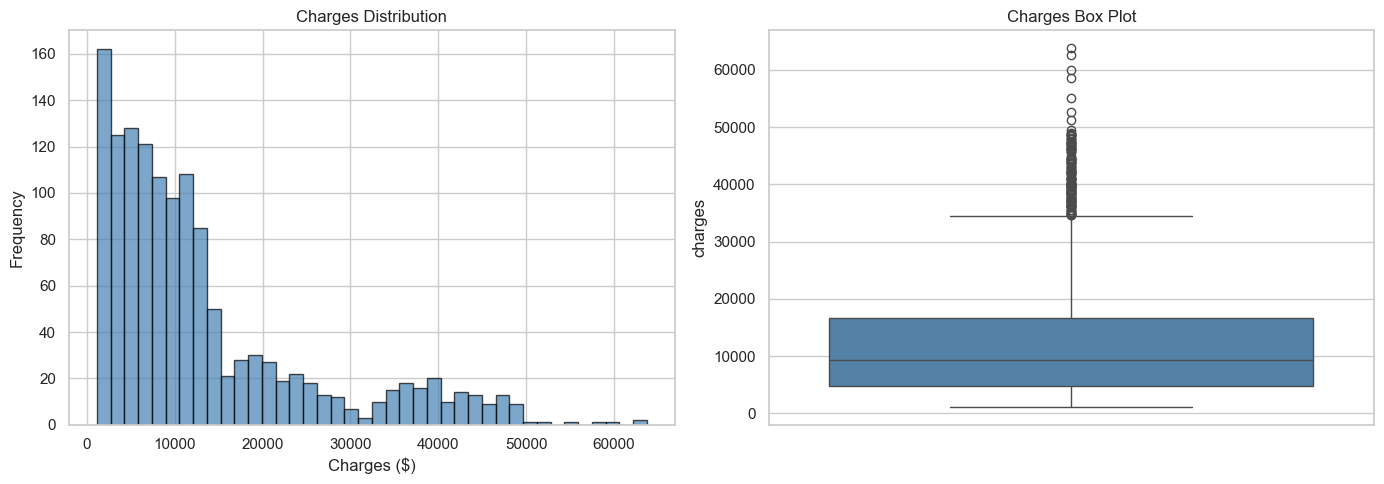

Skewness: 1.52
Kurtosis: 1.61


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["charges"], bins=40, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title("Charges Distribution")
axes[0].set_xlabel("Charges ($)")
axes[0].set_ylabel("Frequency")

# Box plot
sns.boxplot(y=df["charges"], ax=axes[1], color="steelblue")
axes[1].set_title("Charges Box Plot")

plt.tight_layout()
plt.show()

print(f"Skewness: {df['charges'].skew():.2f}")
print(f"Kurtosis: {df['charges'].kurtosis():.2f}")

## 5. Numerical Variables Distribution

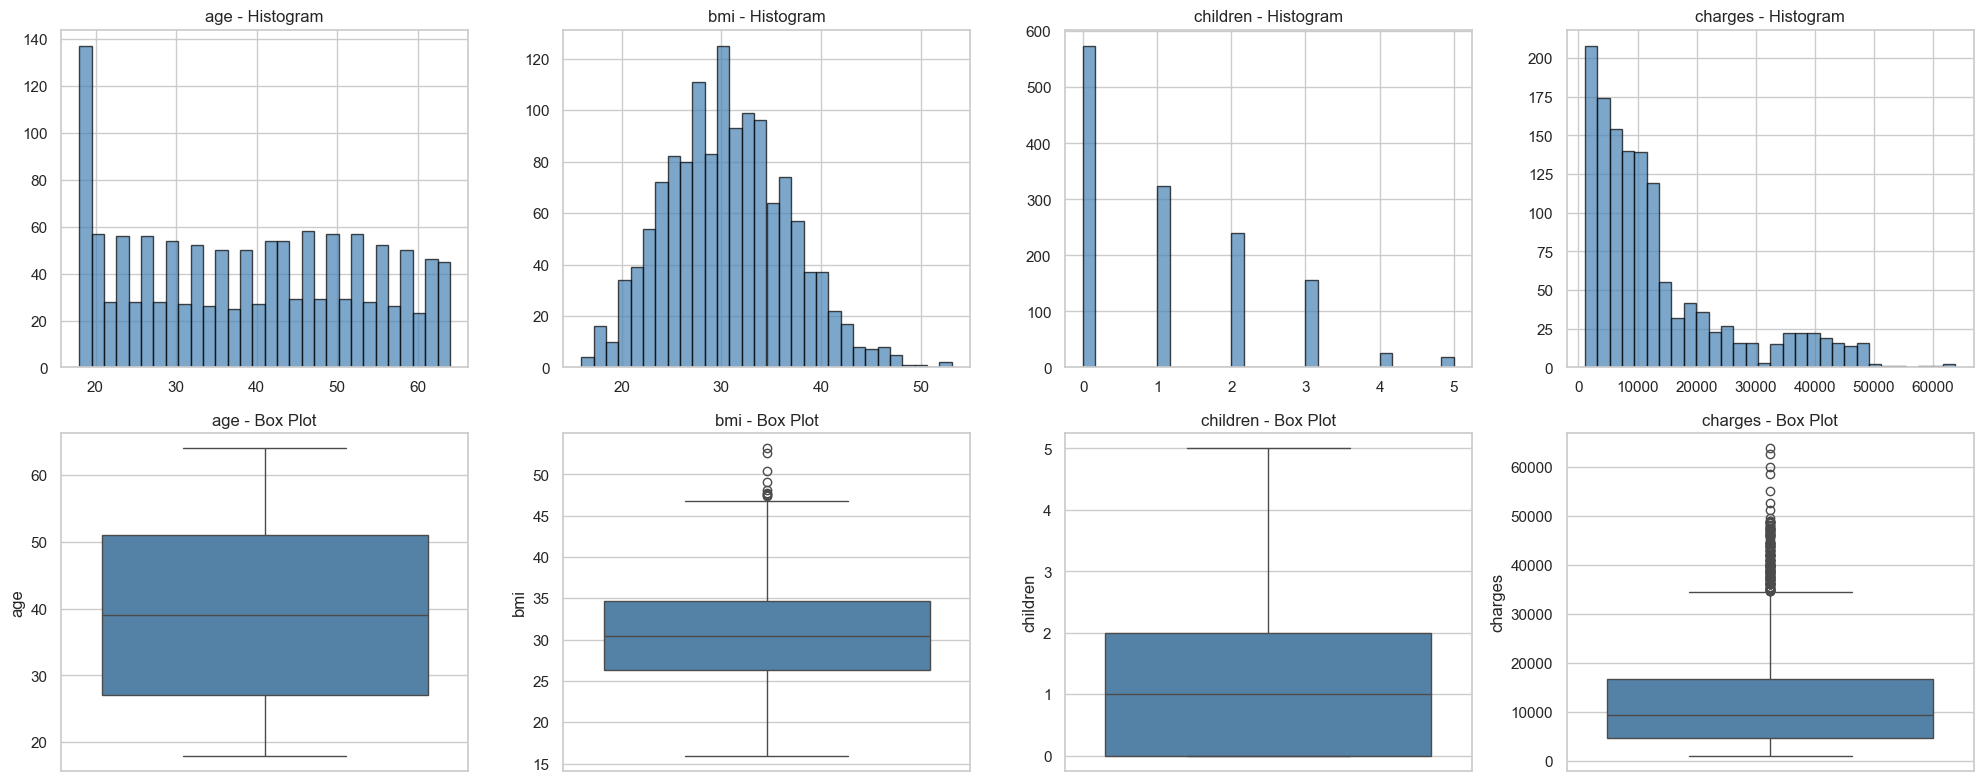

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, len(num_cols), figsize=(5 * len(num_cols), 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    axes[0, i].set_title(f"{col} - Histogram")
    sns.boxplot(y=df[col], ax=axes[1, i], color="steelblue")
    axes[1, i].set_title(f"{col} - Box Plot")

plt.tight_layout()
plt.show()

## 6. Correlation Matrix

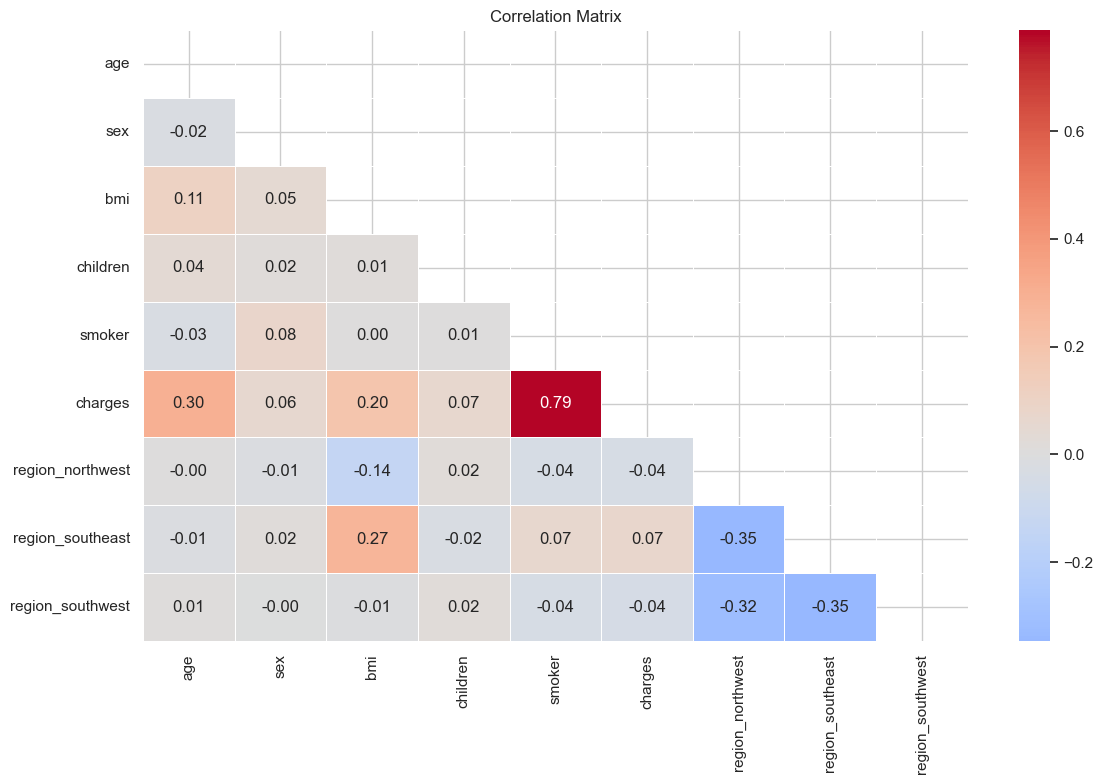

In [13]:
# Encode categorical variables for correlation calculation
df_encoded = df.copy()
df_encoded["sex"] = df_encoded["sex"].map({"male": 1, "female": 0})
df_encoded["smoker"] = df_encoded["smoker"].map({"yes": 1, "no": 0})
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True, dtype=int)

corr = df_encoded.corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
# Correlation ranking with charges
print("Correlation with Charges (descending):")
print(corr["charges"].drop("charges").sort_values(ascending=False).to_string())

Correlation with Charges (descending):
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210


## 7. Relationship Between Features and Charges

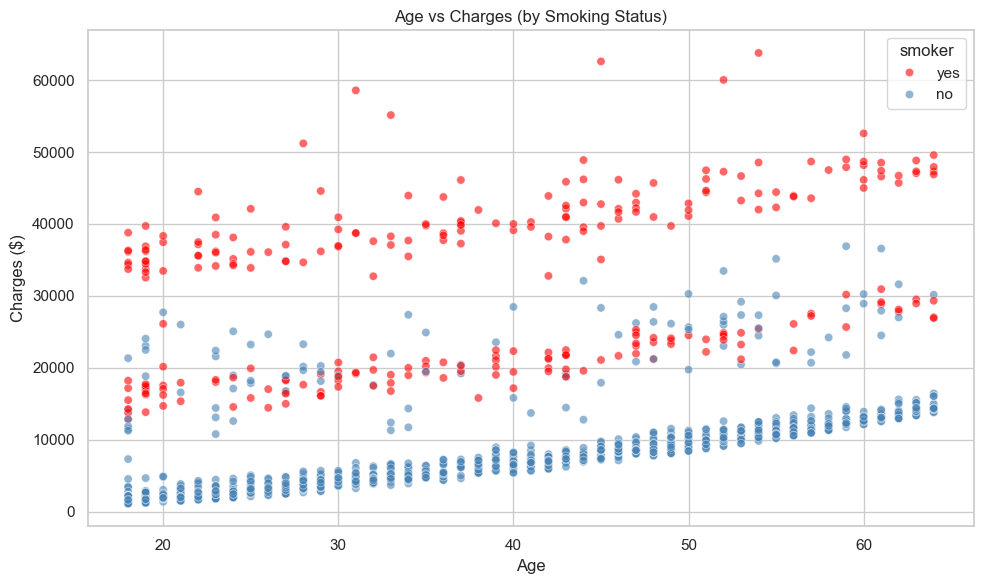

In [15]:
# Age vs Charges (by smoking status)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker",
                palette={"yes": "red", "no": "steelblue"}, alpha=0.6, ax=ax)
ax.set_title("Age vs Charges (by Smoking Status)")
ax.set_xlabel("Age")
ax.set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()

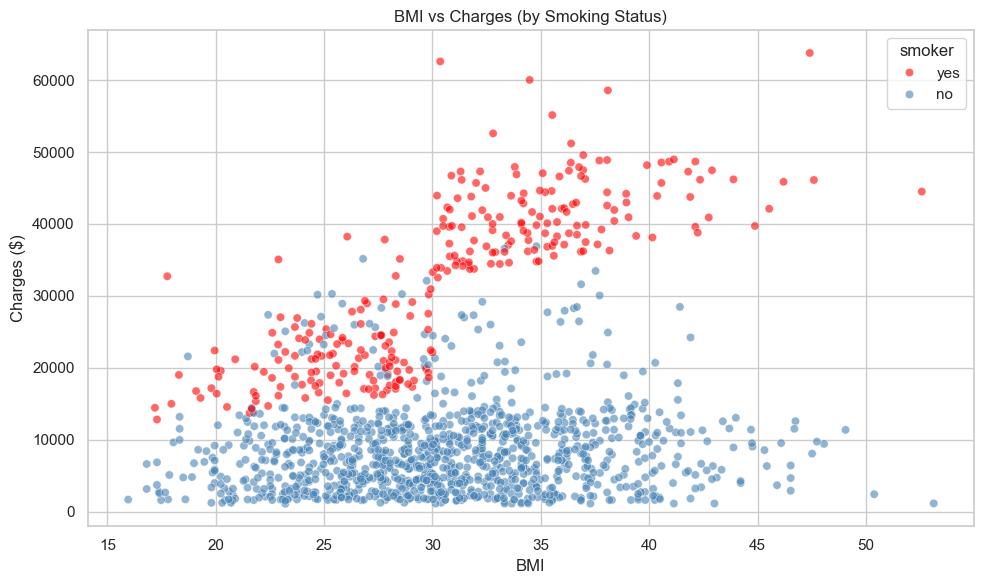

In [16]:
# BMI vs Charges (by smoking status)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker",
                palette={"yes": "red", "no": "steelblue"}, alpha=0.6, ax=ax)
ax.set_title("BMI vs Charges (by Smoking Status)")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges ($)")
plt.tight_layout()
plt.show()

C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\2751652926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=ax, palette="Set2")
C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\2751652926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=ax, palette="Set2")
C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\2751652926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="charges", ax=ax, palette="Set2")
C:\Users\Emre\AppData\Local\Temp\ipykernel_23336\275165

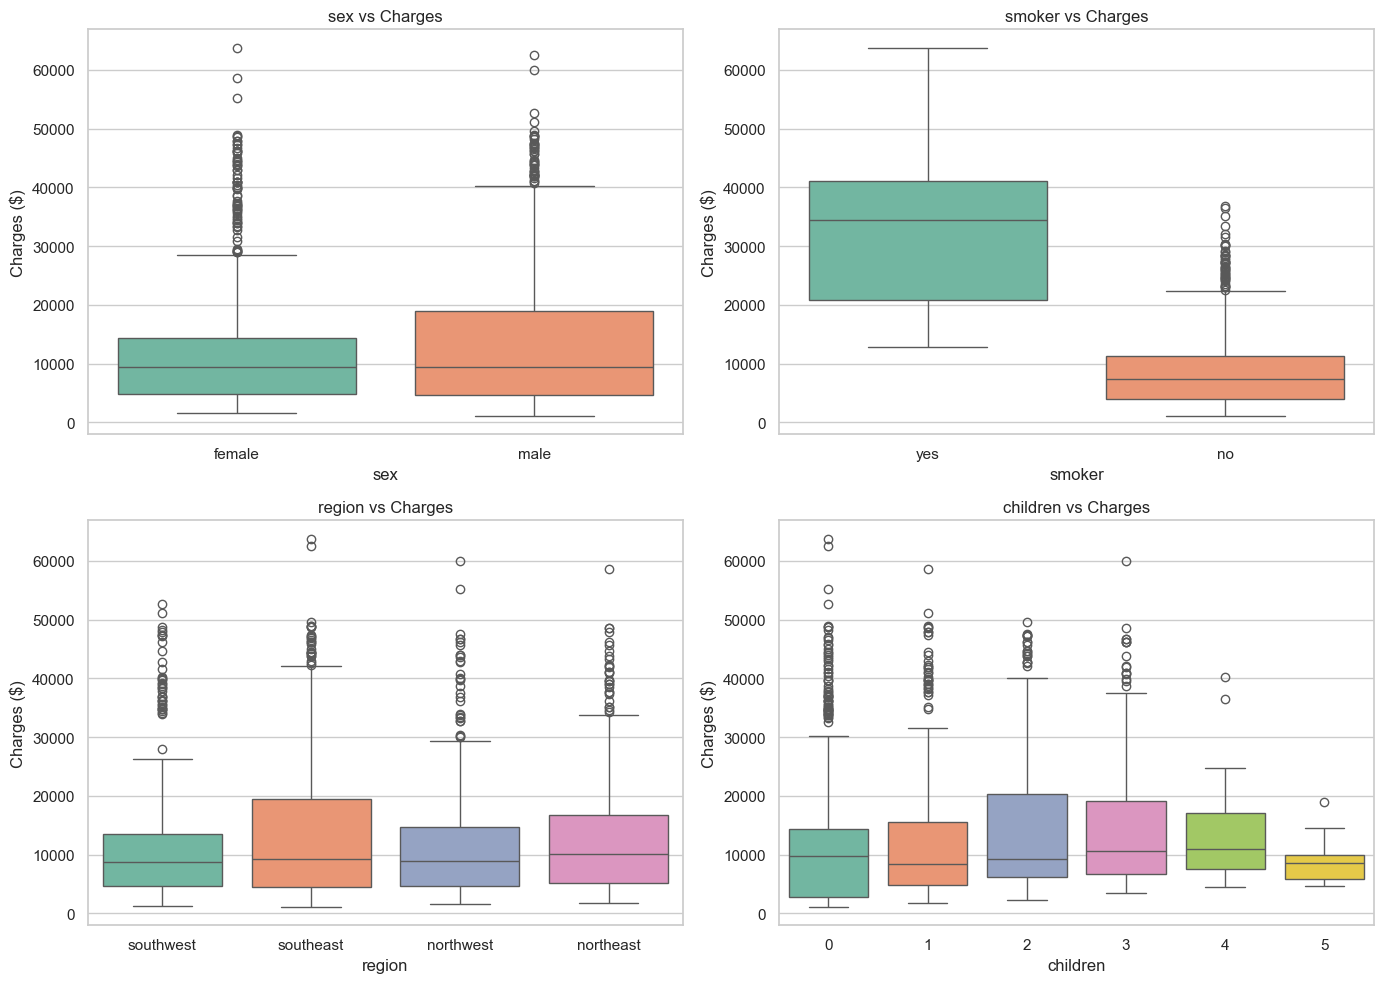

In [17]:
# Kategorik degiskenler vs Charges
cat_cols = ["sex", "smoker", "region", "children"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cat_cols):
    ax = axes[i // 2, i % 2]
    sns.boxplot(data=df, x=col, y="charges", ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Charges")
    ax.set_ylabel("Charges ($)")

plt.tight_layout()
plt.show()

In [18]:
# Average cost by smoking status
print("Average cost by smoking status:")
print(df.groupby("smoker")["charges"].agg(["mean", "median", "std", "count"]))
print(f"\nSmoker cost ratio: "
      f"{df.groupby('smoker')['charges'].mean()['yes'] / df.groupby('smoker')['charges'].mean()['no']:.1f}x")

Average cost by smoking status:
                mean       median           std  count
smoker                                                
no       8434.268298   7345.40530   5993.781819   1064
yes     32050.231832  34456.34845  11541.547176    274

Smoker cost ratio: 3.8x


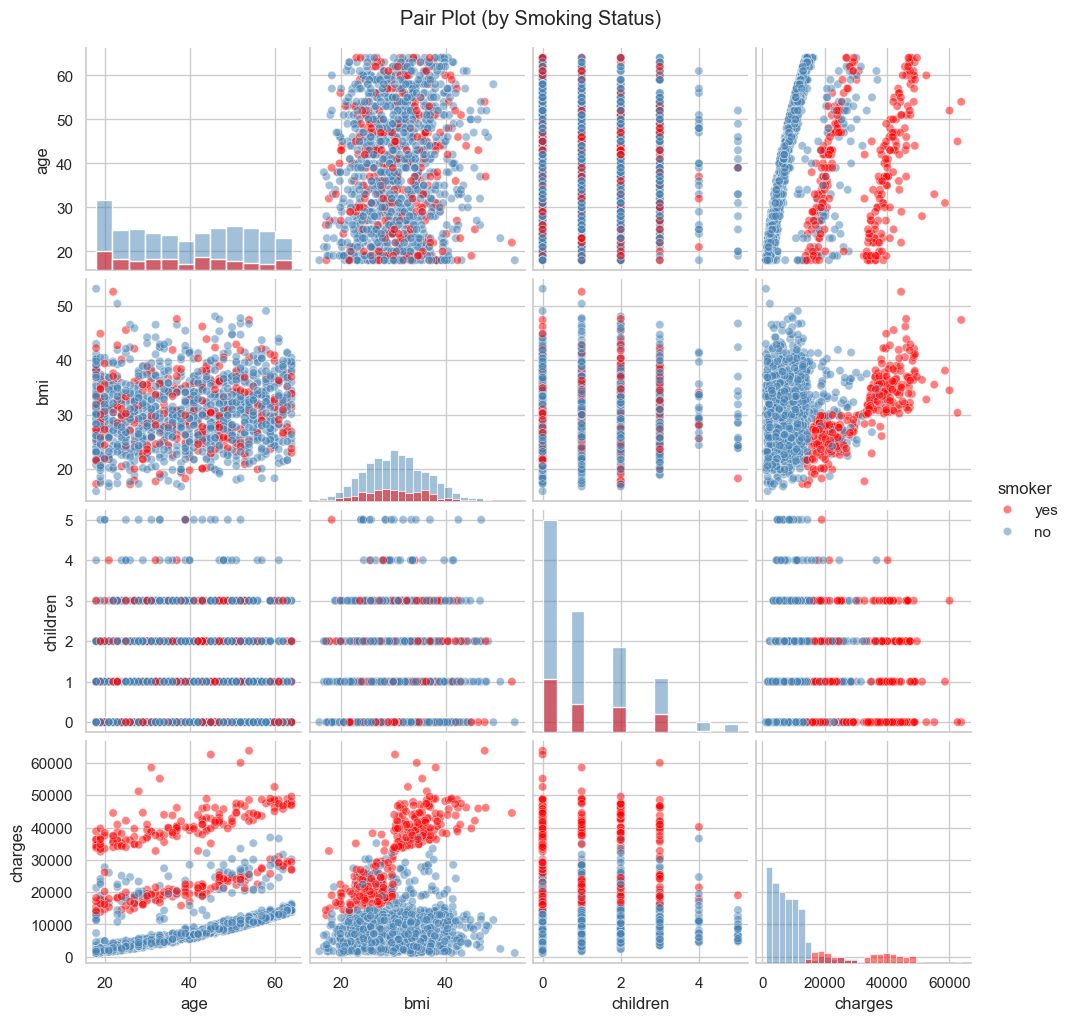

In [19]:
# Pair plot (numerical variables, colored by smoking status)
sns.pairplot(df, hue="smoker", palette={"yes": "red", "no": "steelblue"},
             diag_kind="hist", plot_kws={"alpha": 0.5})
plt.suptitle("Pair Plot (by Smoking Status)", y=1.02)
plt.show()

## 8. Summary of Findings

This section can be filled with insights obtained from the charts after running the notebook.